### RNN(순환 신경망)
- 이전 시점의 정보를 현재 시점에 계산에 반영하는 구조

    - 첫번째 입력
        - 초기 상태(h_0 = 0)와 입력에 대한 상태(h_1)로 계산
    - 두번째 입력
        - 이전의 상태(h_1)와 결합해서 계산 (h_2)
    - 세번째 입력
        - 이전의 입력 상태(h_2) 현재의 상태를 결합해서 계산(h_3)
    - 반복 작업이 완료되었을때 
        - 마지막 상태 (h_t) 생성 -> 모든 과거의 정보를 결합해놓은 상태 

- parameter
    - input_size
        - 각 시점(레이어)에서 입력의 피쳐의 수 
    - hidden_size
        - 은닉층(출력)의 크기 
    - num_layers
        - 기본값 : 1
        - RNN 층의 개수 (층이 깊어질수록 복잡한 패턴을 발생)
        - 층의 개수가 늘어날수록 시간은 증가하고 과적합의 위험성이 존재 
        - 1~3 정도 사용을 하고 1부터 개수를 1씩 증가시키면서 사용
    - nonlinearity
        - 기본값 : 'tanh'
        - 비선형 활성화 함수를 선택 
    - batch_first
        -  기본값 : False
        - 입력 텐서에서 첫번째 차원이 배치인지 여부
    - bias
        - 기본값 : True
        - 각 가중치에 편향 항을 추가 여부
    - dropout
        - 기본값 : 0.0
        - 층 사이에 Dropout의 적용 비율 -> 층이 2개 이상인 경우에만 사용
    - bidirectional
        - 기본값 : False
        - 양방향 RNN을 사용할지 여부 (순방향은 기본, 역방향을 사용할것인가?)

- paramter 설정시 유의할 점 
    - hidden_size
        - 너무 적은 경우라면 정보가 부족, 너무 큰 경우라면 과적합 
        - 일반적으로는 32, 64, 128
    - num_layers
        - 시간의 복잡도에 따라서 1 ~ 3 정도를 이용
        - 1부터 테스트를 돌려서 교차 검증 
    - nonlinearity
        - 일반적으로 'tanh'을 사용. relu를 사용하면 시간이 감소하지만 발산의 위험성이 존재 
    - dropout
        - 층이 2개 이상인 경우에만 사용
        - 과적합 방지를 위해 사용 0.2 ~ 0.5 사이의 값을 사용(권장사항)

In [149]:
import math 
import numpy as np 
import torch 
import torch.nn as nn
import torch.optim as optim
from torch. utils.data import DataLoader, Dataset
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [150]:
#랜덤 시드 고정 
np.random.seed(42)
torch.manual_seed(42)

In [151]:
# 노이즈를 포함한 연속성을 가진 sin곡선을 생성 
x = torch.arange(3000).float()
y = torch.sin( 2 * math.pi * 0.02 * x) + 0.05 * torch.randn(3000)

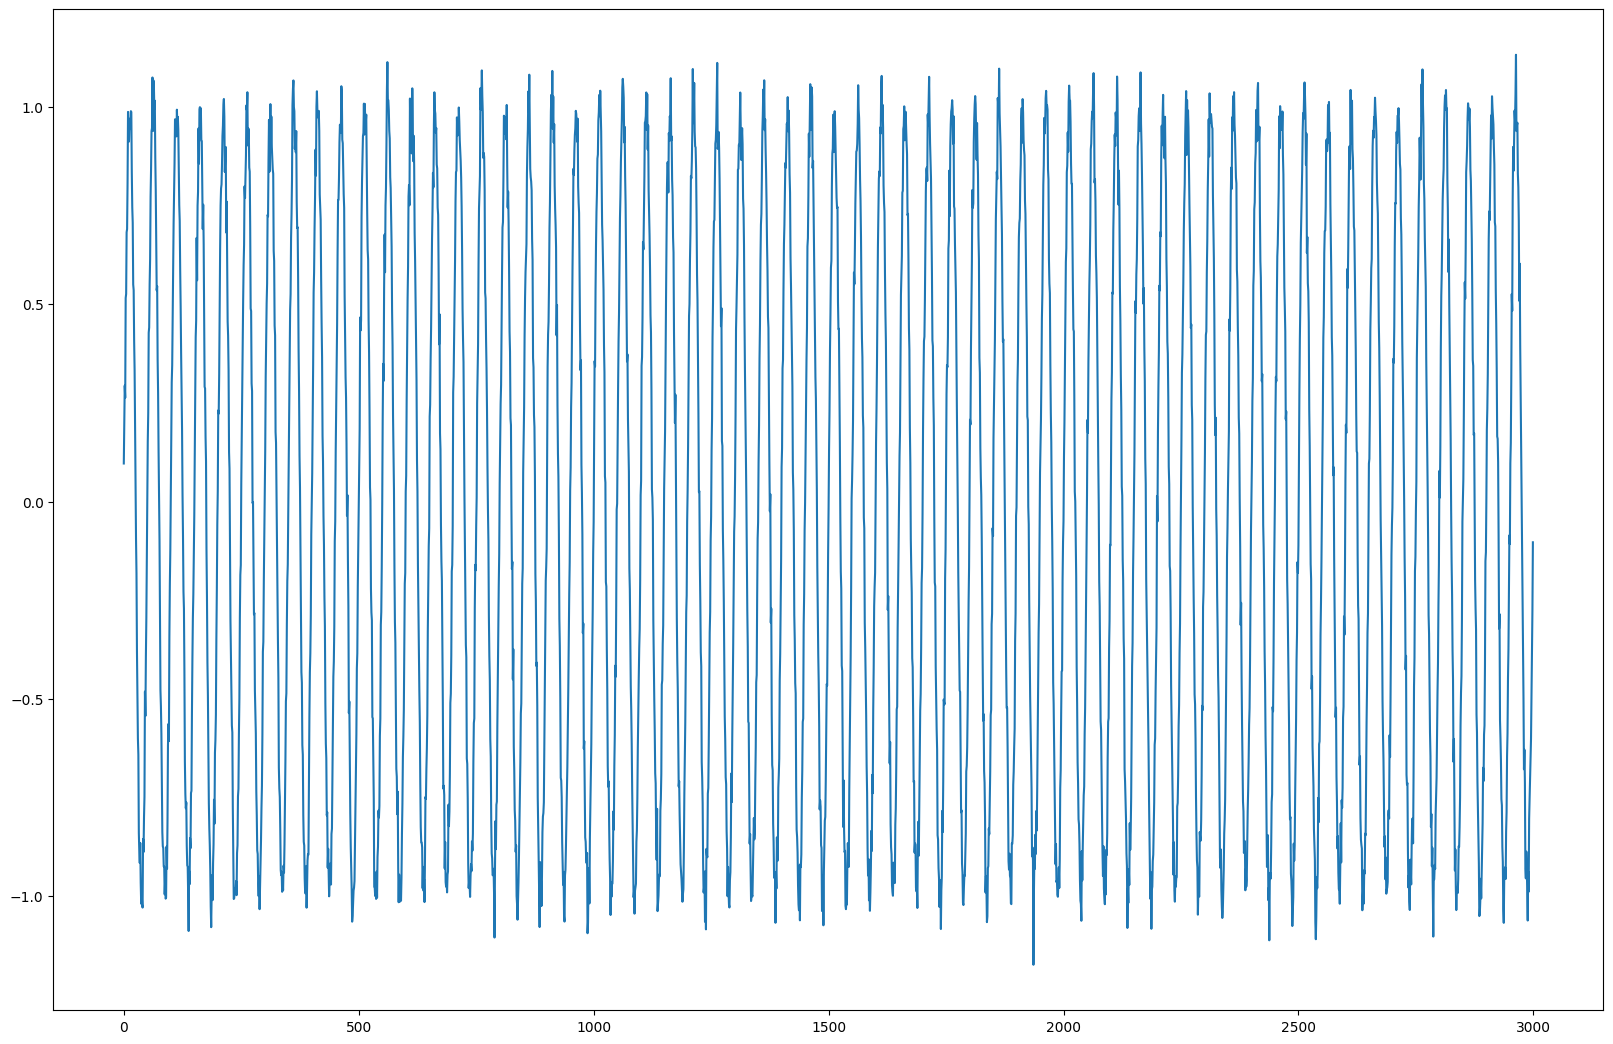

In [152]:
plt.figure(figsize=(20, 13))
plt.plot(x, y)
plt.show()

In [153]:
x

tensor([0.0000e+00, 1.0000e+00, 2.0000e+00,  ..., 2.9970e+03, 2.9980e+03,
        2.9990e+03])

In [154]:
# train, test 데이터셋 분할 8:2 -> 앞의 80% train, 뒤의 20% test
train_size = int(0.8 * len(x))
train_size

2400

In [155]:
# X_train = x[:train_size]
X_train = y[:train_size]
# X_test = x[train_size:]
X_test = y[train_size:]

In [156]:
X_test

tensor([ 0.0207,  0.0991,  0.2554,  0.3119,  0.5472,  0.5841,  0.7407,  0.7583,
         0.8579,  0.8834,  0.9923,  0.9123,  0.9639,  1.0407,  1.0607,  0.9211,
         0.9168,  0.9495,  0.7320,  0.6089,  0.5676,  0.4596,  0.3048,  0.3229,
         0.1151, -0.0594, -0.1183, -0.2164, -0.3797, -0.4620, -0.5946, -0.6721,
        -0.7896, -0.9260, -0.9211, -0.8456, -1.0102, -0.9786, -1.1119, -0.9636,
        -0.9407, -0.9556, -0.8743, -0.7616, -0.7417, -0.5208, -0.5316, -0.3982,
        -0.2048, -0.0887,  0.0137,  0.2113,  0.3159,  0.3049,  0.5043,  0.6208,
         0.6519,  0.7261,  0.7903,  0.9761,  0.8950,  1.0019,  0.9735,  0.9836,
         0.9721,  0.9413,  0.9882,  0.8780,  0.8291,  0.6856,  0.5420,  0.4927,
         0.4309,  0.2083,  0.2284,  0.0152, -0.1984, -0.2588, -0.3666, -0.4672,
        -0.5668, -0.7253, -0.8053, -0.7994, -0.9430, -0.9609, -1.0005, -1.0757,
        -1.0411, -1.0023, -0.8670, -0.9104, -0.8716, -0.7442, -0.6498, -0.5512,
        -0.4016, -0.3324, -0.1535, -0.18

In [157]:
# len(Y_test)

In [158]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train.reshape(-1, 1))
X_test_sc = scaler.transform(X_test.reshape(-1, 1))

In [159]:
X_train_sc

array([[ 0.13549958],
       [ 0.28142013],
       [ 0.41417719],
       ...,
       [-0.56898224],
       [-0.31882725],
       [-0.10808127]], shape=(2400, 1))

In [160]:
X_train_tensor = torch.tensor(X_train_sc, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_sc, dtype=torch.float32)

In [161]:
X_train_tensor.shape

torch.Size([2400, 1])

In [162]:
# Tensor Data를 배치가 존재하는 3차원 데이터로 변환 
X_train_tensor = X_train_tensor.unsqueeze(0)
X_test_tensor = X_test_tensor.unsqueeze(0)

X_train_tensor.shape
  # (2400, 1) -> (2400, 1, 1)

torch.Size([1, 2400, 1])

In [163]:
class RNN_Model(nn.Module):
    def __init__(self):
        super(RNN_Model, self).__init__()
        self.rnn = nn.RNN(
            input_size = 1, 
            hidden_size = 64, 
            num_layers = 1,
            batch_first = True, 
            dropout = 0.0,
            nonlinearity = 'tanh', 
            bidirectional = False
        )
        self.linear = nn.Linear(64, 1)
    def forward(self, x):
        # RNN 모델에서 되돌려주는 데이터는 2개를 되돌려준다. ->
        # 첫번째 데이터 : 모든 시점에서의 은닉층의 값
        # 두번째 데이터 : 마지막 시점에서의 은직층의 값 -> 층이 존재하는 경우 마지막 층의 값을 추출
        out, h_n = self.rnn(x)
        result = self.linear(h_n[-1])
        return result

In [164]:
model = RNN_Model()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

### DataLoader 
- Pytorch에서 DataSet들을 효율적으로 배치 단위로 꺼내주는 반복자
- 반복 학습 루프에 맞는 형태의 데이터셋을 공급해주는 역할
- parameter
    - batch_size
        - Dataset들을 모아서 텐서의 형태로 묶어준다. 
    - shuffle
        - 에폭마다 데이터의 순서를 랜덤하게 변경 
    - drop_last
        - window(구간)에 맞는 구간을 나눠주고 마지막 구간에서 데이터의 개수가 window가 작은 경우에는 해당 배치를 제거 
    - pin_memory
        - GPU 사용시 True로 변경하면 CPU -> GPU 전송이 빨라짐

In [165]:
# Custom Dataset 클래스 정의 
class WindowDataset(Dataset):
    def __init__(self, _data, _window):
        # _data : 시계열 데이터 
        # _ window : 구간 설정 
        self.data = _data
        self.window = _window
        # 유효 샘플의 개수 계산
        # 입력 데이터 : 전체 길이 - window 크기 
        self.n = len(self.data) - self.window
    # __len__ 메서드 : 데이터셋의 크기를 반환
    # __getitem__ 메서드 : 인덱스에 해당하는 샘플을 반환
    # 특수 메서드 : DataLoader가 데이터셋에서 데이터를 불러올때 자동으로 호출 
    def __len__(self):
        return self.n
    
    def __getitem__(self, idx):
        # DataLoader 실제로 입력이 된 데이터들을 슬라이스해서 가지고 가는 함수 
        # idx -> 0 // data[0 : 10] -> idx (0~9) -> 문제 데이터
        x = self.data[idx : idx + self.window]
        # data[10] -> 11번째 데이터 -> 정답 데이터 
        y = self.data[idx + self.window]
        return x, y

In [166]:
window = 10
train_ds = WindowDataset(X_train_tensor.squeeze(0), window)


In [167]:
len(X_train_tensor.squeeze(0))

2400

In [168]:
len(train_ds)

2390

In [169]:
batch_size = 10
x_list = []
y_list = []
for i in range(len(train_ds)):
    if i == 10 : 
        break
    x, y = train_ds[i]
    x_list.append(x)
    y_list.append(y)

In [170]:
train_dl = DataLoader(
    train_ds, 
    batch_size = 64,
    drop_last = True, 
    shuffle = True,
)
test_dl = DataLoader(
    WindowDataset(X_test_tensor.squeeze(0), window),
    batch_size = 64,
    drop_last = True, 
    shuffle = False,
)

In [171]:
# 반복 학습 

train_loss_list = []
test_loss_list = []

for epoch in range(20):
    model.train()

    running = 0.0
    n_seen = 0 

    for x, y in train_dl:
        
        x = x.float()
        y = y.float()

        # print(x, y)
        # RNN 모델에 입력(x)을 넣어서 예측값(yhat)을 얻는다.
        yhat = model(x)
        # 오차 계산
        loss = criterion(yhat, y)
        # 기울기 초기화
        optimizer.zero_grad()
        # 역전파(자동미분)
        loss.backward()
        # 미분값이 폭주 방지 
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        # 가중치의 업데이트 
        optimizer.step()

        running += loss.item() * x.size(0)
        n_seen += x.size(0)
    
    train_loss = running / max(1, n_seen)
    train_loss_list.append(train_loss)
    print(f"Epoch {epoch+1}, Train Loss: {round(train_loss, 8)}")


Epoch 1, Train Loss: 0.10030609
Epoch 2, Train Loss: 0.01078203
Epoch 3, Train Loss: 0.01074139
Epoch 4, Train Loss: 0.01088122
Epoch 5, Train Loss: 0.00999281
Epoch 6, Train Loss: 0.00945274
Epoch 7, Train Loss: 0.01010242
Epoch 8, Train Loss: 0.01187644
Epoch 9, Train Loss: 0.00868531
Epoch 10, Train Loss: 0.0091127
Epoch 11, Train Loss: 0.00888444
Epoch 12, Train Loss: 0.00872168
Epoch 13, Train Loss: 0.00930924
Epoch 14, Train Loss: 0.00947859
Epoch 15, Train Loss: 0.00961495
Epoch 16, Train Loss: 0.00855202
Epoch 17, Train Loss: 0.00901214
Epoch 18, Train Loss: 0.00883705
Epoch 19, Train Loss: 0.0092663
Epoch 20, Train Loss: 0.01005977


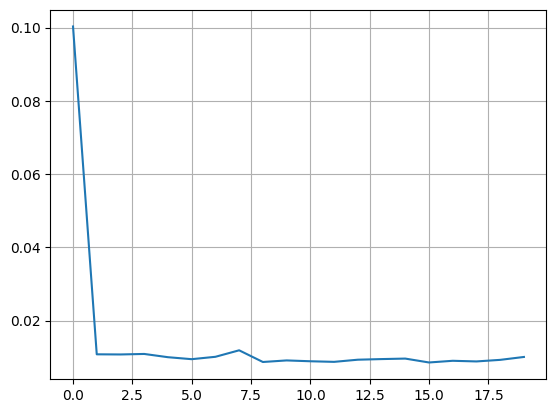

In [172]:
plt.plot(train_loss_list)
plt.grid()
plt.show()

In [173]:
# 예측 데이터 
model.eval()
preds = []
trues = []
with torch.no_grad():
    for x, y in test_dl:
        x = x.float()
        y = y.float()
        pred = model(x)
        preds.append(pred)
        trues.append(y)

In [174]:
preds = torch.cat(preds, 0).squeeze(-1).numpy()
trues = torch.cat(trues, 0).squeeze(-1).numpy()

In [175]:
len(preds)

576

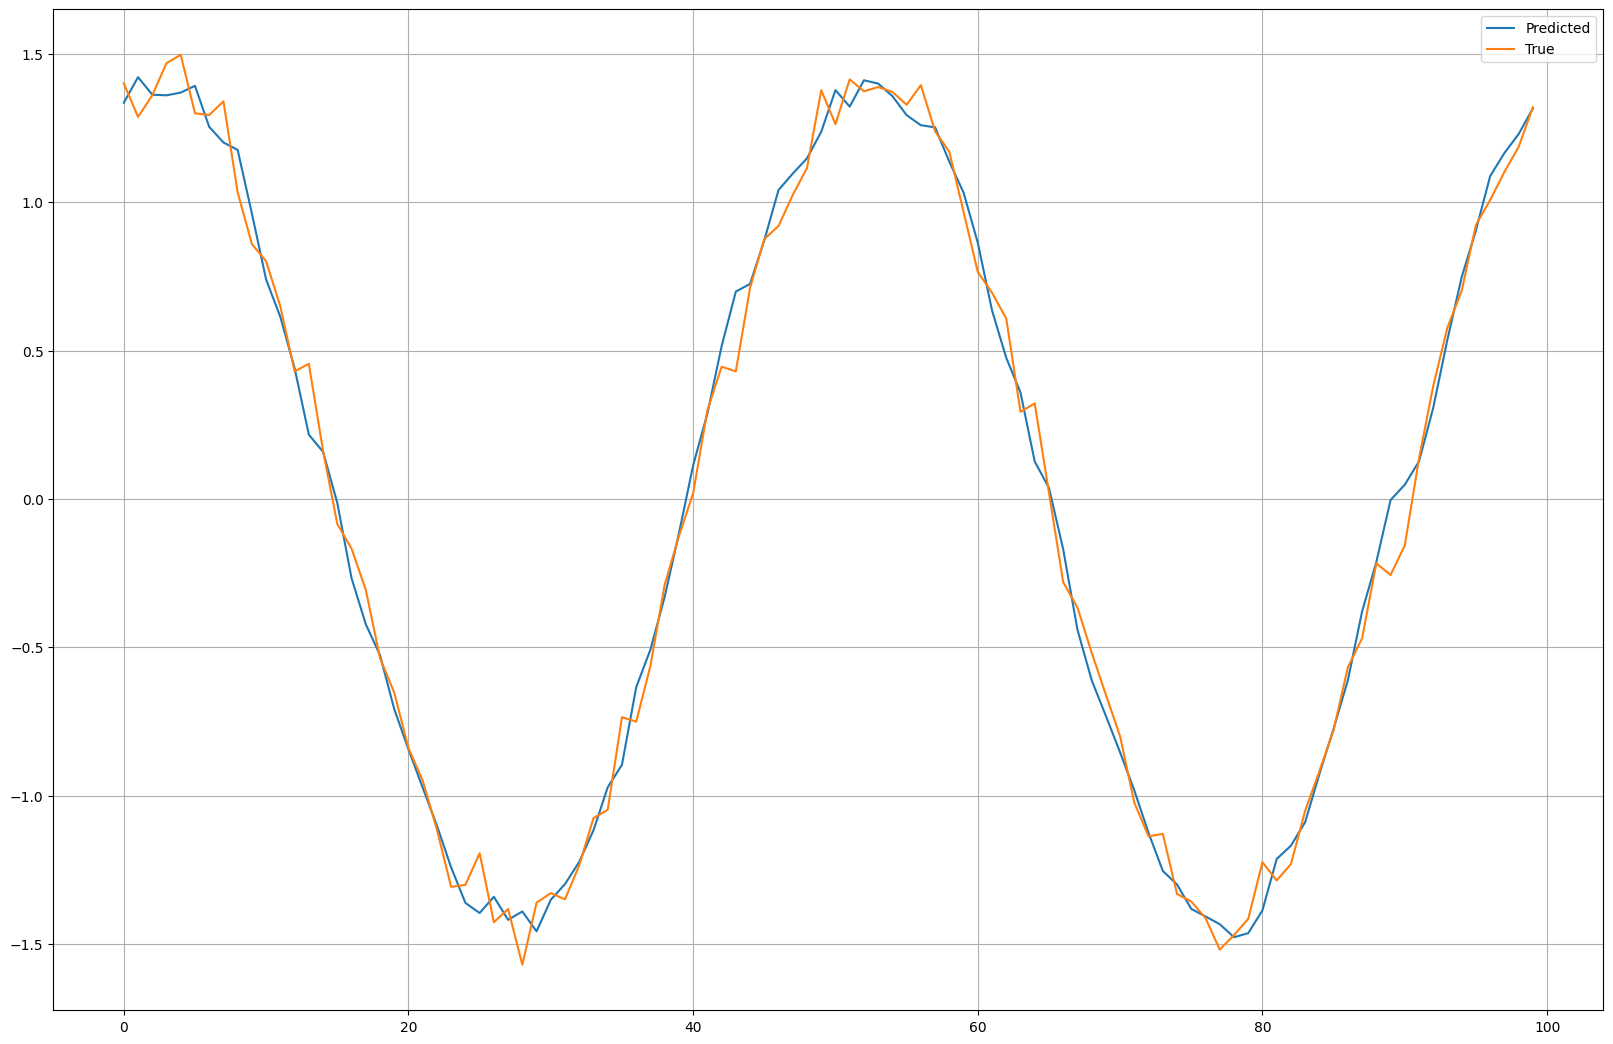

In [177]:
plt.figure(figsize=(20, 13))
plt.plot(preds[:100], label='Predicted')
plt.plot(trues[:100], label='True')
plt.legend()
plt.grid()
plt.show()